# Filter-Based Feature Selection Runtime Analysis

This notebook is the main experiment entrypoint. It compares mRMR, ReliefF, and CFS-Greedy on stratified Gisette subsamples from 10% to 100% of the labeled dataset.

## 1. Imports and Constants

In [1]:
from __future__ import annotations

import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.sparse import issparse
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from algorithms import select_cfs_greedy, select_mrmr, select_relieff
from utils.data_loader import load_dataset

DATASET_NAME = "gisette"
RANDOM_STATE = 42
FRACTIONS = [round(value / 10, 1) for value in range(1, 11)]
TOP_K_RATIO = 0.10
TEST_SIZE = 0.20

RESULTS_DIR = Path("results") / "filter_analysis"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)


## 2. Shared Helpers

In [2]:
def matrix_nonzero_count(x) -> int:
    if issparse(x):
        return int(x.nnz)
    return int(np.count_nonzero(x))


def matrix_density(x) -> float:
    total_cells = x.shape[0] * x.shape[1]
    if total_cells == 0:
        return 0.0
    return matrix_nonzero_count(x) / total_cells


def class_distribution_text(y: np.ndarray) -> str:
    labels, counts = np.unique(y, return_counts=True)
    distribution = {str(label): int(count) for label, count in zip(labels, counts)}
    return json.dumps(distribution, sort_keys=True)


def json_text(value: object) -> str:
    return json.dumps(value, default=str, sort_keys=True)


def selected_indices_text(indices: np.ndarray) -> str:
    return ";".join(str(int(index)) for index in indices)


def make_nested_stratified_subsets(
    y: np.ndarray,
    fractions: list[float] = FRACTIONS,
    random_state: int = RANDOM_STATE,
) -> dict[float, np.ndarray]:
    rng = np.random.default_rng(random_state)
    shuffled_by_class: dict[object, np.ndarray] = {}
    for label in np.unique(y):
        class_indices = np.flatnonzero(y == label)
        shuffled_by_class[label] = rng.permutation(class_indices)

    subsets: dict[float, np.ndarray] = {}
    for fraction in fractions:
        selected_parts: list[np.ndarray] = []
        for class_indices in shuffled_by_class.values():
            selected_count = int(round(len(class_indices) * fraction))
            selected_count = max(1, min(selected_count, len(class_indices)))
            selected_parts.append(class_indices[:selected_count])
        selected_indices = np.concatenate(selected_parts)
        selected_indices.sort()
        subsets[fraction] = selected_indices
    return subsets


def train_test_scale(x_subset, y_subset, random_state: int):
    x_train, x_test, y_train, y_test = train_test_split(
        x_subset,
        y_subset,
        test_size=TEST_SIZE,
        random_state=random_state,
        stratify=y_subset,
    )
    scaler = StandardScaler(with_mean=not issparse(x_train))
    x_train_scaled = scaler.fit_transform(x_train)
    x_test_scaled = scaler.transform(x_test)
    return x_train_scaled, x_test_scaled, y_train, y_test


def train_and_evaluate_linear_svm(x_train, y_train, x_test, y_test, mask: np.ndarray | None = None) -> tuple[float, float]:
    if mask is not None:
        mask = mask.astype(bool)
        x_train = x_train[:, mask]
        x_test = x_test[:, mask]

    model = SGDClassifier(
        loss="hinge",
        alpha=0.0001,
        max_iter=1000,
        tol=1e-3,
        random_state=RANDOM_STATE,
    )
    start = time.perf_counter()
    model.fit(x_train, y_train)
    train_time_seconds = time.perf_counter() - start
    predictions = model.predict(x_test)
    test_accuracy = accuracy_score(y_test, predictions)
    return train_time_seconds, test_accuracy


## 3. Load Gisette and Summarize Input Sizes

In [3]:
x, y, feature_names = load_dataset(DATASET_NAME)
if issparse(x):
    x = x.tocsr()

n_rows, n_features = x.shape
TOP_K = max(1, int(round(n_features * TOP_K_RATIO)))
subsets = make_nested_stratified_subsets(y)

summary_rows = []
for fraction, indices in subsets.items():
    x_subset = x[indices]
    y_subset = y[indices]
    summary_rows.append(
        {
            "dataset": DATASET_NAME,
            "fraction": fraction,
            "rows": int(x_subset.shape[0]),
            "features": int(x_subset.shape[1]),
            "input_size": int(x_subset.shape[0] * x_subset.shape[1]),
            "nonzero_count": matrix_nonzero_count(x_subset),
            "density": matrix_density(x_subset),
            "class_distribution": class_distribution_text(y_subset),
        }
    )

subsample_summary = pd.DataFrame(summary_rows)
subsample_summary.to_csv(RESULTS_DIR / "gisette_subsample_summary.csv", index=False)
print(f"Top-k feature cap: {TOP_K} of {n_features} features")
display(subsample_summary)


Top-k feature cap: 500 of 5000 features


,dataset,fraction,rows,features,input_size,nonzero_count,density,class_distribution
0,gisette,0.1,700,5000,3500000,3470051,0.991443,"{""-1"": 350, ""1"": 350}"
1,gisette,0.2,1400,5000,7000000,6940135,0.991448,"{""-1"": 700, ""1"": 700}"
2,gisette,0.3,2100,5000,10500000,10410171,0.991445,"{""-1"": 1050, ""1"": 1050}"
3,gisette,0.4,2800,5000,14000000,13880415,0.991458,"{""-1"": 1400, ""1"": 1400}"
4,gisette,0.5,3500,5000,17500000,17350450,0.991454,"{""-1"": 1750, ""1"": 1750}"
5,gisette,0.6,4200,5000,21000000,20820278,0.991442,"{""-1"": 2100, ""1"": 2100}"
6,gisette,0.7,4900,5000,24500000,24290410,0.991445,"{""-1"": 2450, ""1"": 2450}"
7,gisette,0.8,5600,5000,28000000,27760606,0.991450,"{""-1"": 2800, ""1"": 2800}"
8,gisette,0.9,6300,5000,31500000,31230962,0.991459,"{""-1"": 3150, ""1"": 3150}"
9,gisette,1.0,7000,5000,35000000,34700997,0.991457,"{""-1"": 3500, ""1"": 3500}"


## 4. Full-Feature Baseline Linear SVM

In [4]:
x_train_full, x_test_full, y_train_full, y_test_full = train_test_scale(x, y, RANDOM_STATE)
baseline_train_time, baseline_accuracy = train_and_evaluate_linear_svm(
    x_train_full,
    y_train_full,
    x_test_full,
    y_test_full,
    mask=None,
)

baseline_result = pd.DataFrame(
    [
        {
            "model": "Baseline",
            "fraction": 1.0,
            "rows": int(x.shape[0]),
            "features": int(x.shape[1]),
            "input_size": int(x.shape[0] * x.shape[1]),
            "selected_count": int(x.shape[1]),
            "svm_train_time_seconds": baseline_train_time,
            "test_accuracy": baseline_accuracy,
        }
    ]
)
baseline_result.to_csv(RESULTS_DIR / "baseline_result.csv", index=False)
display(baseline_result)


,model,fraction,rows,features,input_size,selected_count,svm_train_time_seconds,test_accuracy
0,Baseline,1.0,7000,5000,35000000,5000,29.124177,0.982143


## 5. Run Filter Feature Selection

In [5]:
ALGORITHMS = {
    "mRMR": lambda x_train, y_train: select_mrmr(x_train, y_train, top_k=TOP_K),
    "ReliefF": lambda x_train, y_train: select_relieff(x_train, y_train, top_k=TOP_K, random_state=RANDOM_STATE),
    "CFS-Greedy": lambda x_train, y_train: select_cfs_greedy(x_train, y_train, max_features=TOP_K),
}

result_rows: list[dict[str, object]] = []
for fraction_index, (fraction, indices) in enumerate(subsets.items(), start=1):
    x_subset = x[indices]
    y_subset = y[indices]
    x_train, x_test, y_train, y_test = train_test_scale(
        x_subset,
        y_subset,
        RANDOM_STATE + fraction_index,
    )

    for algorithm_name, selector in ALGORITHMS.items():
        print(f"Running {algorithm_name} on fraction={fraction:.1f}, rows={x_subset.shape[0]}", flush=True)
        selection_start = time.perf_counter()
        selection_result = selector(x_train, y_train)
        selection_runtime = time.perf_counter() - selection_start

        svm_train_time, test_accuracy = train_and_evaluate_linear_svm(
            x_train,
            y_train,
            x_test,
            y_test,
            selection_result.mask,
        )
        total_runtime = selection_runtime + svm_train_time
        selected_count = int(selection_result.mask.sum())

        result_rows.append(
            {
                "dataset": DATASET_NAME,
                "algorithm": algorithm_name,
                "fraction": fraction,
                "rows": int(x_subset.shape[0]),
                "features": int(x_subset.shape[1]),
                "input_size": int(x_subset.shape[0] * x_subset.shape[1]),
                "nonzero_count": matrix_nonzero_count(x_subset),
                "density": matrix_density(x_subset),
                "selected_count": selected_count,
                "selection_runtime_seconds": selection_runtime,
                "svm_train_time_seconds": svm_train_time,
                "total_runtime_seconds": total_runtime,
                "test_accuracy": test_accuracy,
                "selected_feature_indices": selected_indices_text(selection_result.selected_indices),
                "metadata": json_text(selection_result.metadata),
            }
        )
        pd.DataFrame(result_rows).to_csv(RESULTS_DIR / "filter_feature_selection_results.csv", index=False)
        print(
            f"  selected={selected_count}, selection_time={selection_runtime:.4f}s, "
            f"svm_time={svm_train_time:.4f}s, accuracy={test_accuracy:.4f}",
            flush=True,
        )

filter_results = pd.DataFrame(result_rows)
display(filter_results)


Running mRMR on fraction=0.1, rows=700
  selected=500, selection_time=4.7531s, svm_time=0.0440s, accuracy=0.9714
Running ReliefF on fraction=0.1, rows=700
  selected=500, selection_time=3.0847s, svm_time=0.0321s, accuracy=0.9429
Running CFS-Greedy on fraction=0.1, rows=700
  selected=61, selection_time=0.3838s, svm_time=0.0027s, accuracy=0.8714
Running mRMR on fraction=0.2, rows=1400
  selected=500, selection_time=8.2063s, svm_time=0.0518s, accuracy=0.9536
Running ReliefF on fraction=0.2, rows=1400
  selected=500, selection_time=9.0054s, svm_time=0.0835s, accuracy=0.9286
Running CFS-Greedy on fraction=0.2, rows=1400
  selected=57, selection_time=0.4483s, svm_time=0.0061s, accuracy=0.9071
Running mRMR on fraction=0.3, rows=2100
  selected=500, selection_time=11.3811s, svm_time=0.1916s, accuracy=0.9667
Running ReliefF on fraction=0.3, rows=2100
  selected=500, selection_time=17.8121s, svm_time=0.0944s, accuracy=0.9690
Running CFS-Greedy on fraction=0.3, rows=2100
  selected=54, selection

,dataset,algorithm,fraction,rows,features,input_size,nonzero_count,density,selected_count,selection_runtime_seconds,svm_train_time_seconds,total_runtime_seconds,test_accuracy,selected_feature_indices,metadata
0,gisette,mRMR,0.1,700,5000,3500000,3470051,0.991443,500,4.753094,0.043984,4.797078,0.971429,3656;1170;557;576;4353;4507;4386;904;4424;3002...,"{""history"": [{""feature"": 3656, ""redundancy"": 0..."
1,gisette,ReliefF,0.1,700,5000,3500000,3470051,0.991443,500,3.084670,0.032072,3.116742,0.942857,3656;557;4507;4386;3975;2301;511;2742;3463;416...,"{""feature_weights"": ""[-0.00320762 -0.00100618 ..."
2,gisette,CFS-Greedy,0.1,700,5000,3500000,3470051,0.991443,61,0.383831,0.002724,0.386555,0.871429,3656;557;3065;467;4424;1228;4158;455;4386;4267...,"{""best_merit"": 0.8713859366389024, ""candidate_..."
3,gisette,mRMR,0.2,1400,5000,7000000,6940135,0.991448,500,8.206297,0.051750,8.258047,0.953571,3656;356;557;4164;4353;3002;4424;1228;4386;450...,"{""history"": [{""feature"": 3656, ""redundancy"": 0..."
4,gisette,ReliefF,0.2,1400,5000,7000000,6940135,0.991448,500,9.005400,0.083463,9.088862,0.928571,3656;557;4507;4386;3463;2301;3002;214;3975;416...,"{""feature_weights"": ""[ 0.00807415 -0.00492046 ..."
5,gisette,CFS-Greedy,0.2,1400,5000,7000000,6940135,0.991448,57,0.448299,0.006050,0.454349,0.907143,3656;557;904;4424;4445;3065;4386;3463;467;3002...,"{""best_merit"": 0.8604657438356825, ""candidate_..."
6,gisette,mRMR,0.3,2100,5000,10500000,10410171,0.991445,500,11.381129,0.191639,11.572769,0.966667,3656;2099;4386;554;579;4507;3002;4353;3065;557...,"{""history"": [{""feature"": 3656, ""redundancy"": 0..."
7,gisette,ReliefF,0.3,2100,5000,10500000,10410171,0.991445,500,17.812070,0.094400,17.906470,0.969048,3656;557;4507;4386;3463;2301;1228;3002;3975;51...,"{""feature_weights"": ""[ 0.00590415 -0.00382954 ..."
8,gisette,CFS-Greedy,0.3,2100,5000,10500000,10410171,0.991445,54,0.629001,0.009553,0.638555,0.935714,3656;3002;4424;467;3065;4386;2099;4507;3061;12...,"{""best_merit"": 0.8450384027237638, ""candidate_..."
9,gisette,mRMR,0.4,2800,5000,14000000,13880415,0.991458,500,14.525618,0.118496,14.644114,0.950000,3656;2099;3065;4386;3463;3002;4424;1228;467;55...,"{""history"": [{""feature"": 3656, ""redundancy"": 0..."


## 6. Plot Execution Time, Selected Features, and Best Accuracy

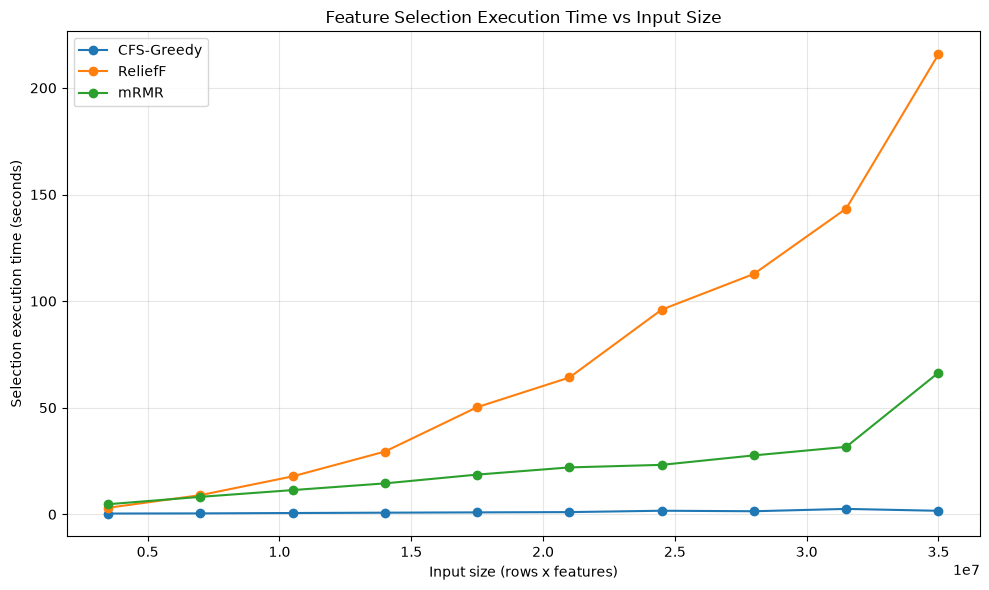

Saved plot: results\filter_analysis\execution_time_vs_input_size.png


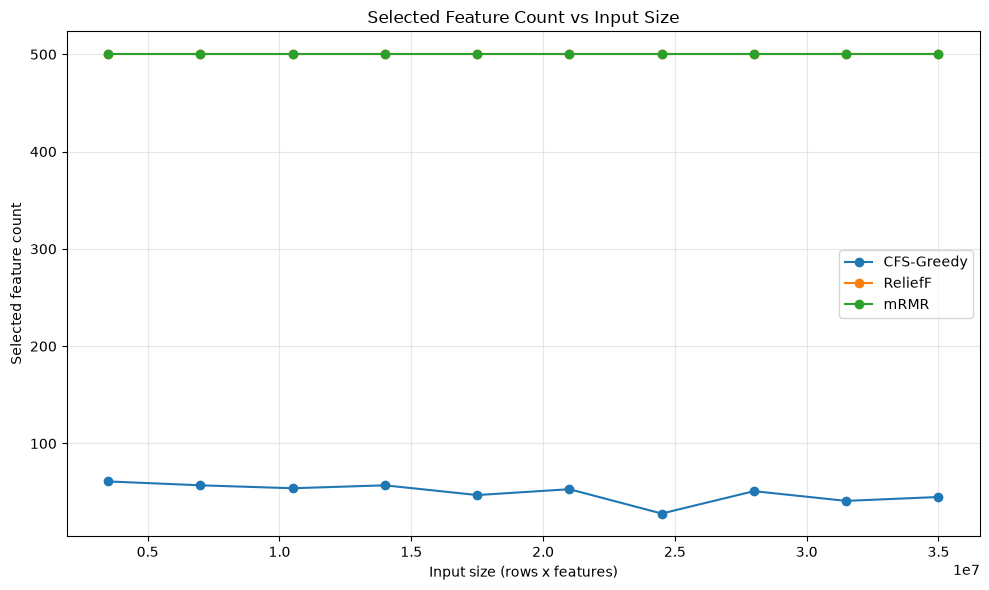

Saved plot: results\filter_analysis\selected_features_vs_input_size.png


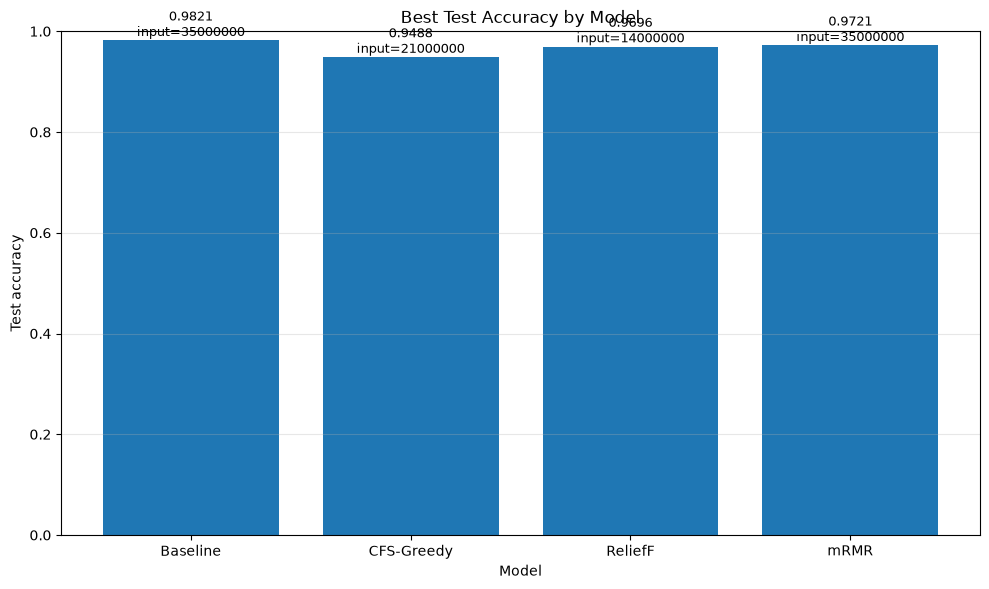

Saved plot: results\filter_analysis\best_accuracy_comparison.png


,model,test_accuracy,input_size
0,Baseline,0.982143,35000000
1,CFS-Greedy,0.948810,21000000
2,ReliefF,0.969643,14000000
3,mRMR,0.972143,35000000


In [6]:
filter_results = pd.read_csv(RESULTS_DIR / "filter_feature_selection_results.csv")
baseline_result = pd.read_csv(RESULTS_DIR / "baseline_result.csv")

figure, axis = plt.subplots(figsize=(10, 6))
for algorithm_name, algorithm_results in filter_results.groupby("algorithm"):
    algorithm_results = algorithm_results.sort_values("input_size")
    axis.plot(
        algorithm_results["input_size"],
        algorithm_results["selection_runtime_seconds"],
        marker="o",
        label=algorithm_name,
    )
axis.set_title("Feature Selection Execution Time vs Input Size")
axis.set_xlabel("Input size (rows x features)")
axis.set_ylabel("Selection execution time (seconds)")
axis.grid(True, alpha=0.3)
axis.legend()
figure.tight_layout()
execution_plot_path = RESULTS_DIR / "execution_time_vs_input_size.png"
figure.savefig(execution_plot_path, dpi=200)
plt.show()
print(f"Saved plot: {execution_plot_path}")

figure, axis = plt.subplots(figsize=(10, 6))
for algorithm_name, algorithm_results in filter_results.groupby("algorithm"):
    algorithm_results = algorithm_results.sort_values("input_size")
    axis.plot(
        algorithm_results["input_size"],
        algorithm_results["selected_count"],
        marker="o",
        label=algorithm_name,
    )
axis.set_title("Selected Feature Count vs Input Size")
axis.set_xlabel("Input size (rows x features)")
axis.set_ylabel("Selected feature count")
axis.grid(True, alpha=0.3)
axis.legend()
figure.tight_layout()
selected_plot_path = RESULTS_DIR / "selected_features_vs_input_size.png"
figure.savefig(selected_plot_path, dpi=200)
plt.show()
print(f"Saved plot: {selected_plot_path}")

best_rows = [
    {
        "model": "Baseline",
        "test_accuracy": float(baseline_result.loc[0, "test_accuracy"]),
        "input_size": int(baseline_result.loc[0, "input_size"]),
    }
]
for algorithm_name, algorithm_results in filter_results.groupby("algorithm"):
    best_row = algorithm_results.sort_values("test_accuracy", ascending=False).iloc[0]
    best_rows.append(
        {
            "model": algorithm_name,
            "test_accuracy": float(best_row["test_accuracy"]),
            "input_size": int(best_row["input_size"]),
        }
    )

best_accuracy = pd.DataFrame(best_rows)
best_accuracy.to_csv(RESULTS_DIR / "best_accuracy_summary.csv", index=False)

figure, axis = plt.subplots(figsize=(10, 6))
bars = axis.bar(best_accuracy["model"], best_accuracy["test_accuracy"])
axis.set_title("Best Test Accuracy by Model")
axis.set_xlabel("Model")
axis.set_ylabel("Test accuracy")
axis.set_ylim(0, min(1.0, max(best_accuracy["test_accuracy"]) + 0.05))
axis.grid(True, axis="y", alpha=0.3)
for bar, (_, row) in zip(bars, best_accuracy.iterrows()):
    axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{row['test_accuracy']:.4f}\ninput={int(row['input_size'])}",
        ha="center",
        va="bottom",
        fontsize=9,
    )
figure.tight_layout()
accuracy_plot_path = RESULTS_DIR / "best_accuracy_comparison.png"
figure.savefig(accuracy_plot_path, dpi=200)
plt.show()
print(f"Saved plot: {accuracy_plot_path}")
display(best_accuracy)
